In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [35]:
df=pd.read_csv('Student Social Media And Mental Health Impact.csv')


In [36]:
df.shape

(5000, 13)

In [37]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [38]:
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [39]:
df.duplicated().sum()

np.int64(2)

In [40]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


**EDA**

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

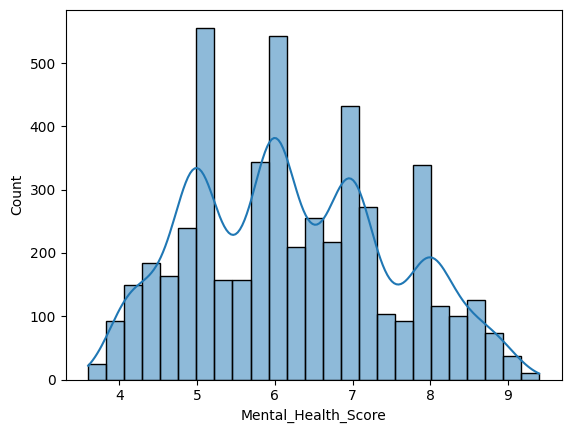

In [41]:
sns.histplot(df['Mental_Health_Score'],kde=True)

<Axes: >

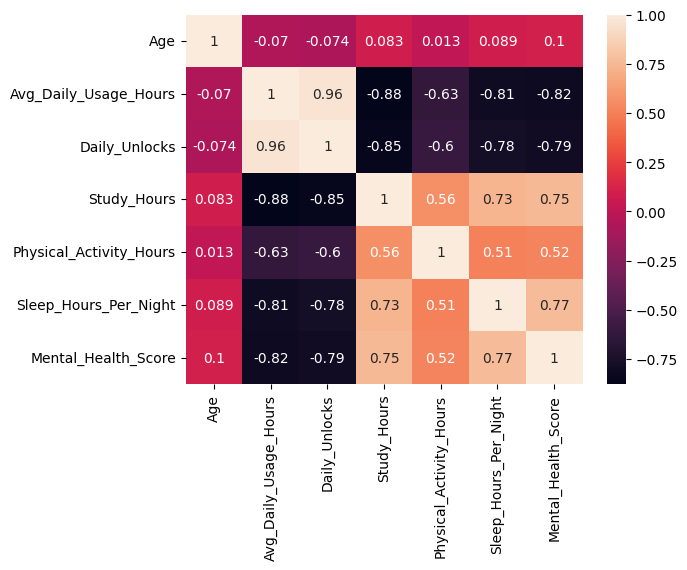

In [42]:
sns.heatmap(df.corr(numeric_only=True ),annot=True)

In [43]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

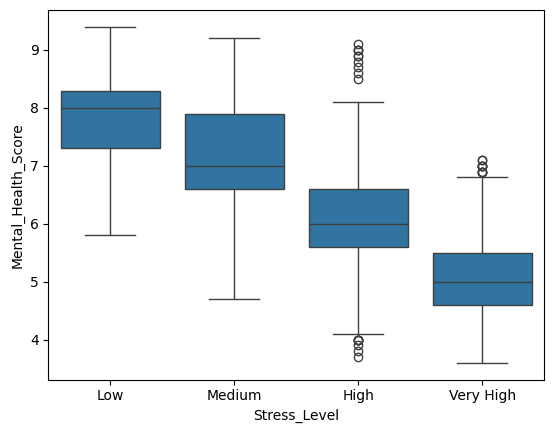

In [44]:
order=['Low','Medium','High','Very High']
sns.boxplot(x='Stress_Level',y='Mental_Health_Score',data=df,order=order)

In [45]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

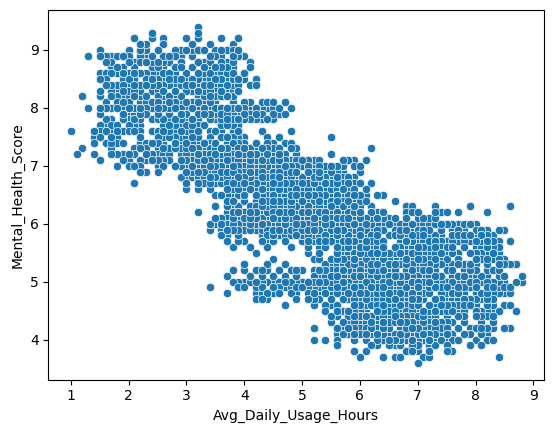

In [46]:
sns.scatterplot(x='Avg_Daily_Usage_Hours',y='Mental_Health_Score',data=df)

<Axes: xlabel='Mental_Health_Score', ylabel='Sleep_Hours_Per_Night'>

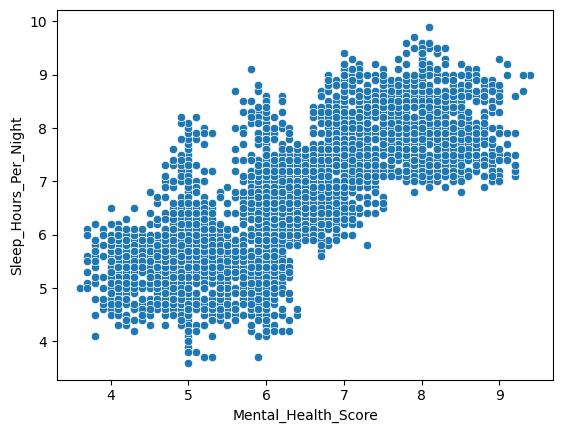

In [47]:
sns.scatterplot(x='Mental_Health_Score',y='Sleep_Hours_Per_Night',data=df)

**Checking outliers**

In [48]:
num_features=df.select_dtypes(include='number')
Q1=num_features.quantile(0.25)
Q3=num_features.quantile(0.75)
IQR=Q3-Q1
lb=Q1-1.5*IQR
ub=Q3+1.5*IQR
outliers=(num_features<lb) | (num_features>ub)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


**DATA** **CLEANING**

In [49]:
#1.drop duplicates
df=df.drop_duplicates()
#2. coverting -ve and unrealisitc value to realistic value
df['Physical_Activity_Hours']=df['Physical_Activity_Hours'].clip(lower=0)

In [50]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


# Skewness


In [51]:
num_features=df.select_dtypes(include='number')

num_features.skew() #skew ki value near to zero=centralized agar -ve to leftskewed and +ve right


,0
Age,0.155008
Avg_Daily_Usage_Hours,0.005575
Daily_Unlocks,0.002309
Study_Hours,0.436125
Physical_Activity_Hours,0.053288
Sleep_Hours_Per_Night,0.123919
Mental_Health_Score,0.207086


# Feature engineering

In [52]:
top_countries=df['Country'].value_counts().index[:10].to_list()

In [53]:
def group_countries(x):
    if x in top_countries:
        return x
    else:
        return 'Other'

In [54]:
df['Grouped_country']=df['Country'].apply(group_countries)
df['Grouped_country'].value_counts()

,count
Grouped_country,
Other,3231
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94


# Train test spilit

In [55]:
from sklearn.model_selection import train_test_split


skwes_cols=['Study_Hours']

other_numeric_cols=['Age','Avg_Daily_Usage_Hours','Daily_Unlocks','Physical_Activity_Hours',
                    'Sleep_Hours_Per_Night']
ordinal_col=['Stress_Level']
normal_col=['Gender','Academic_Level','Most_Used_Platform','Purpose_Of_Use','Grouped_country']
feature_col=skwes_cols+other_numeric_cols+ordinal_col+normal_col
X=df[feature_col]
y=df['Mental_Health_Score']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=42)

# PREPROCESSING USING COLUMN TRANSFORMATION

In [56]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer,StandardScaler,OrdinalEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer


#PIPELINE
#1. Skewed_pipeline
skew_pipeline=Pipeline(steps=[
    ('log_transformer',FunctionTransformer(np.log1p)),('scale',StandardScaler())
])
#2. Numeric features
numeric_pipeline=Pipeline(steps=[
    ('scale',StandardScaler())
])
#3. ordinal
ordinal_pipeline=Pipeline(steps=[('encode',OrdinalEncoder(categories=[['Low','Medium','High','Very High']]))])
#4.nominal
nominal_pipeline=Pipeline(steps=[('encode',OneHotEncoder(handle_unknown='ignore'))])

preprocessor=ColumnTransformer(transformers=[("skewed_pipeline",skew_pipeline,skwes_cols),
                                ("plain_numeric_Pipeline",numeric_pipeline,other_numeric_cols),("ordinal_pipeline",ordinal_pipeline,ordinal_col),("Nomial_pipeline",nominal_pipeline,normal_col)])


# baseline:linear regression


In [57]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
lr_pipeline=Pipeline(steps=[('preprocessing',preprocessor),('regressor',LinearRegression())])
lr_pipeline.fit(X_train,y_train)
lr_pred=lr_pipeline.predict(X_test)
print(f'MSE: {mean_squared_error(y_test,lr_pred)}')
print(f'MAE: {mean_absolute_error(y_test,lr_pred)}')
print(f'R2: {r2_score(y_test,lr_pred)}')

MSE: 0.45701905273487986
MAE: 0.5361775634720181
R2: 0.7397944617433021


# Random forest

In [58]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
rf_pipeline=Pipeline(steps=[('preprocessing',preprocessor),('regressor',RandomForestRegressor())])
rf_pipeline.fit(X_train,y_train)
rf_pred=rf_pipeline.predict(X_test)
print(f'MSE: {mean_squared_error(y_test,rf_pred)}')
print(f'MAE: {mean_absolute_error(y_test,rf_pred)}')
print(f'R2: {r2_score(y_test,rf_pred)}')

MSE: 0.21388812858166667
MAE: 0.3456615000000002
R2: 0.8782219793873753


# Random forest with hyperparameter tuning

In [61]:
from sklearn.model_selection import RandomizedSearchCV
param_grid={
    'regressor__n_estimators':[100,200,300],
    'regressor__max_depth':[5,10,15],
    'regressor__min_samples_split':[2,5,10],
    'regressor__min_samples_leaf':[1,2,4]
}
random_search=RandomizedSearchCV(rf_pipeline,param_distributions=param_grid,n_iter=15,cv=5,scoring='r2',random_state=42,n_jobs=-1)
random_search.fit(X_train,y_train)


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(transformers=[('skewed_pipeline',
                                                                               Pipeline(steps=[('log_transformer',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scale',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('plain_numeric_Pipeline',
                                                                               Pipeline(steps=[('scale',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Avg_Daily_Usage_Hours',
                                                                                'Daily_...
                                                                               ['Gender',
                                                                                'Academic_Level',
                                                                                'Most_Used_Platform',
                                                                                'Purpose_Of_Use',
                                                                                'Grouped_country'])])),
                                             ('regressor',
                                              RandomForestRegressor())]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'regressor__max_depth': [5, 10, 15],
                                        'regressor__min_samples_leaf': [1, 2,
                                                                        4],
                                        'regressor__min_samples_split': [2, 5,
                                                                         10],
                                        'regressor__n_estimators': [100, 200,
                                                                    300]},
                   random_state=42, scoring='r2')

In [62]:
random_search.best_params_

{'regressor__n_estimators': 300,
 'regressor__min_samples_split': 5,
 'regressor__min_samples_leaf': 2,
 'regressor__max_depth': 15}

In [64]:
rf_bestpipeline=random_search.best_estimator_
rf_bestpred=rf_bestpipeline.predict(X_test)
print(f'MSE: {mean_squared_error(y_test,rf_bestpred)}')
print(f'MAE: {mean_absolute_error(y_test,rf_bestpred)}')
print(f'R2: {r2_score(y_test,rf_bestpred)}')

MSE: 0.23669729097810674
MAE: 0.3675328963628423
R2: 0.8652354959070179


# Save the model

In [65]:
import joblib
joblib.dump(rf_pipeline,'mental_health_model.pkl')

['mental_health_model.pkl']

In [ ]:
import sklearn
print(sklearn.__version__)